<a href="https://colab.research.google.com/github/keneshawatt/whatsapp-chat-analyzer/blob/main/whatsapp_chat_analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
!pip install -q wordcloud emoji vaderSentiment urlextract

import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import emoji

sns.set_style("whitegrid")
%matplotlib inline

In [20]:
from google.colab import files
uploaded = files.upload()   # click "Choose Files" and pick your exported .txt
file_name = list(uploaded.keys())[0]
with open(file_name, encoding="utf-8") as f:
    data = f.read()

print(data[:400])
print(f"\n...({len(data.splitlines())} lines loaded)")

Saving sample_chat.txt to sample_chat.txt
Messages and calls are end-to-end encrypted. No one outside of this chat, not even WhatsApp, can read or listen to them.
[2/1/26, 9:44:00 AM] Sneha: that's a relief
[2/1/26, 12:28:00 PM] Sneha: <sticker omitted>
[2/1/26, 1:25:00 PM] Sneha: should we plan the trip for next month or the one after
[2/1/26, 2:13:00 PM] Vikram: same, let's lock that in
[2/1/26, 3:15:00 PM] Rahul: yes! what time
[2/1/26

...(401 lines loaded)


In [21]:

print(repr(data[:500]))

"Messages and calls are end-to-end encrypted. No one outside of this chat, not even WhatsApp, can read or listen to them.\n[2/1/26, 9:44:00 AM] Sneha: that's a relief\n[2/1/26, 12:28:00 PM] Sneha: <sticker omitted>\n[2/1/26, 1:25:00 PM] Sneha: should we plan the trip for next month or the one after\n[2/1/26, 2:13:00 PM] Vikram: same, let's lock that in\n[2/1/26, 3:15:00 PM] Rahul: yes! what time\n[2/1/26, 4:51:00 PM] Vikram: yeah honestly\n[2/1/26, 5:10:00 PM] Rahul: weekend can't come soon enough\n[2/1/"


In [22]:
#PRE PROCESSING

MESSAGE_PATTERN = re.compile(
    r"\[(\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}:\d{2}\s?[APap][Mm])\]\s"
)

def preprocess(data):
    messages = MESSAGE_PATTERN.split(data)[1:]
    dates, contents = messages[0::2], messages[1::2]
    df = pd.DataFrame({"date_str": dates, "user_message": contents})

    cleaned = df["date_str"].str.replace("\u202f", " ", regex=False).str.strip()
    df["date"] = pd.to_datetime(cleaned, format="%m/%d/%y, %I:%M:%S %p", errors="coerce")
    df.drop(columns=["date_str"], inplace=True)

    users, texts = [], []
    for message in df["user_message"]:
        entry = re.split(r"([^:]+?):\s", message, maxsplit=1)
        if len(entry) >= 3:
            users.append(entry[1].strip())
            texts.append(entry[2].strip())
        else:
            users.append("group_notification")
            texts.append(message.strip())

    df["user"], df["message"] = users, texts
    df.drop(columns=["user_message"], inplace=True)
    df = df.dropna(subset=["date"]).reset_index(drop=True)

    df["only_date"] = df["date"].dt.date
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month_name()
    df["day_name"] = df["date"].dt.day_name()
    df["hour"] = df["date"].dt.hour
    return df

df = preprocess(data)
df.head()


,date,user,message,only_date,year,month,day_name,hour
0,2026-02-01 09:44:00,Sneha,that's a relief,2026-02-01,2026,February,Sunday,9
1,2026-02-01 12:28:00,Sneha,<sticker omitted>,2026-02-01,2026,February,Sunday,12
2,2026-02-01 13:25:00,Sneha,should we plan the trip for next month or the ...,2026-02-01,2026,February,Sunday,13
3,2026-02-01 14:13:00,Vikram,"same, let's lock that in",2026-02-01,2026,February,Sunday,14
4,2026-02-01 15:15:00,Rahul,yes! what time,2026-02-01,2026,February,Sunday,15


In [23]:
#Exploratory Data Analysis
num_messages = df.shape[0]
num_words = sum(len(m.split()) for m in df["message"])
num_media = df[df["message"] == "<Media omitted>"].shape[0]

print(f"Total messages: {num_messages}")
print(f"Total words:    {num_words}")
print(f"Media shared:   {num_media}")


Total messages: 400
Total words:    1867
Media shared:   0


/tmp/ipykernel_5446/2813322372.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=busy_users.index, y=busy_users.values, palette="viridis")


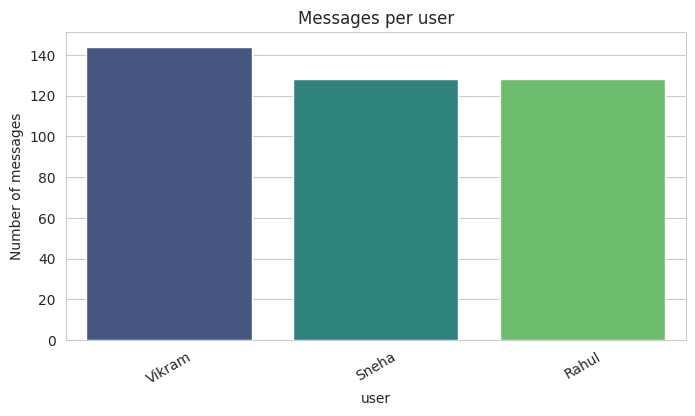

In [24]:
busy_users = df[df["user"] != "group_notification"]["user"].value_counts()

plt.figure(figsize=(8, 4))
sns.barplot(x=busy_users.index, y=busy_users.values, palette="viridis")
plt.title("Messages per user")
plt.ylabel("Number of messages")
plt.xticks(rotation=30)
plt.show()


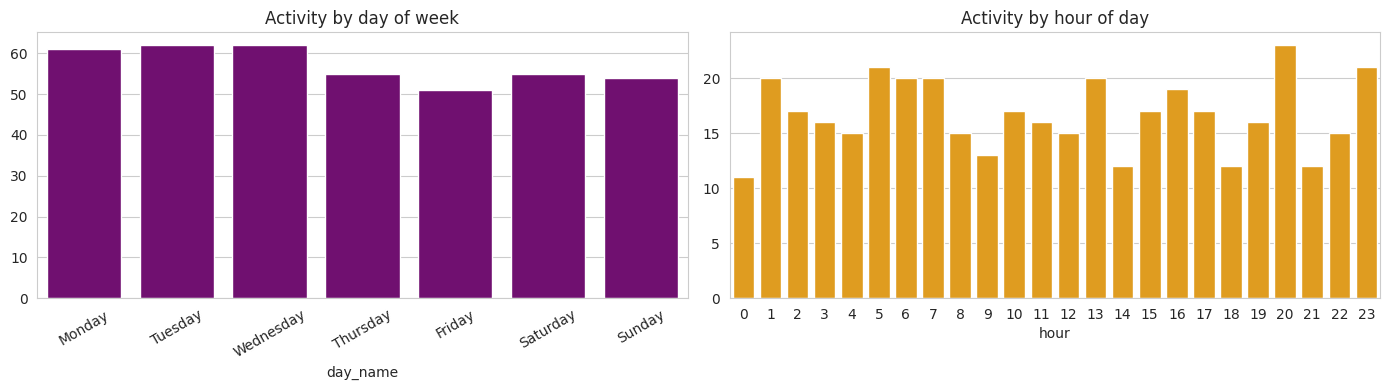

In [25]:
day_counts = df["day_name"].value_counts().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)
hour_counts = df["hour"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(x=day_counts.index, y=day_counts.values, ax=axes[0], color="purple")
axes[0].set_title("Activity by day of week")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(x=hour_counts.index, y=hour_counts.values, ax=axes[1], color="orange")
axes[1].set_title("Activity by hour of day")
plt.tight_layout()
plt.show()

/tmp/ipykernel_5446/2982240146.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="count", y="word", data=common_words, palette="mako")


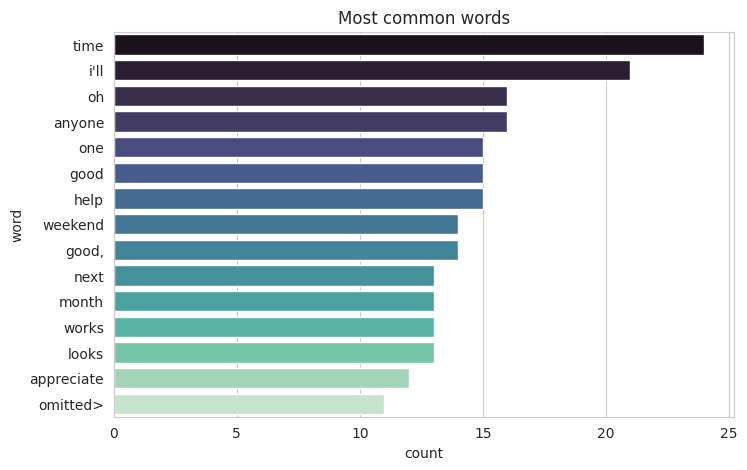

In [26]:
#Text Analysis — word frequency, word cloud, emoji usage
STOP_WORDS = set(['a', 'about', 'above', 'after', 'again', 'against', 'all', 'am', 'an', 'and', 'any', 'are', 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'did', 'do', 'does', 'doing', 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'has', 'have', 'having', 'he', 'her', 'here', 'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', 'if', 'in', 'into', 'is', 'it', 'its', 'itself', 'just', 'me', 'more', 'most', 'my', 'myself', 'no', 'nor', 'not', 'now', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 's', 'same', 'she', 'should', 'so', 'some', 'such', 't', 'than', 'that', 'the', 'their', 'theirs', 'them', 'themselves', 'then', 'there', 'these', 'they', 'this', 'those', 'through', 'to', 'too', 'under', 'until', 'up', 'very', 'was', 'we', 'were', 'what', 'when', 'where', 'which', 'while', 'who', 'whom', 'why', 'will', 'with', 'you', 'your', 'yours', 'yourself', 'yourselves', 'media', 'omitted', 'deleted', 'message', 'this', 'haha', 'hahaha', 'lol', 'ok', 'okay', 'yeah', 'ya', 'hmm', 'hmmm', 'im', 'its', 'ki', 'ka', 'ke', 'ko', 'hai', 'ho', 'haan', 'nahi', 'h', 'na', 'se', 'ye', 'wo', 'mai', 'mera', 'teri', 'tera', 'bhi', 'kya', 'kyu', 'kyun', 'kar', 'karo', 'kro', 'tha', 'thi', 'the'])

def clean_messages(frame):
    temp = frame[frame["user"] != "group_notification"]
    temp = temp[temp["message"] != "<Media omitted>"]
    return temp

text_df = clean_messages(df)

words = []
for message in text_df["message"]:
    for w in message.lower().split():
        if w not in STOP_WORDS:
            words.append(w)

common_words = pd.DataFrame(Counter(words).most_common(15), columns=["word", "count"])

plt.figure(figsize=(8, 5))
sns.barplot(x="count", y="word", data=common_words, palette="mako")
plt.title("Most common words")
plt.show()

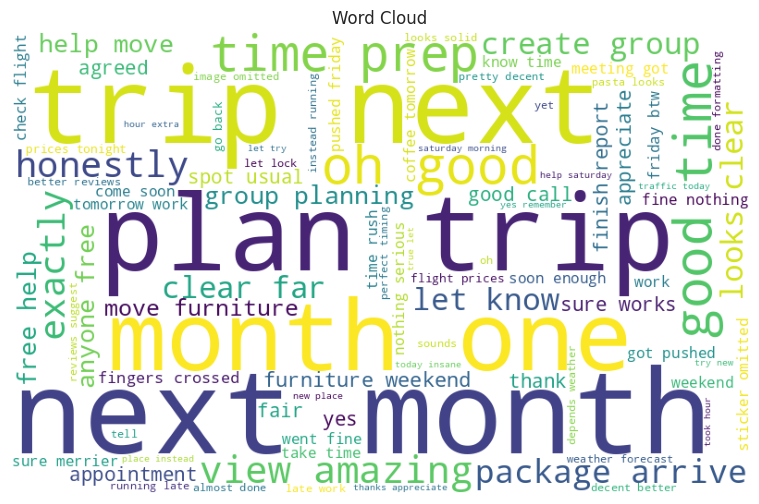

In [27]:
wc = WordCloud(width=800, height=500, background_color="white", min_font_size=10)
wordcloud_img = wc.generate(" ".join(words) if words else "no words available")

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_img)
plt.axis("off")
plt.title("Word Cloud")
plt.show()


In [28]:
emojis = [c for message in df["message"] for c in message if c in emoji.EMOJI_DATA]
emoji_df = pd.DataFrame(Counter(emojis).most_common(10), columns=["emoji", "count"])
emoji_df

,emoji,count
0,😂,9
1,👍,5


In [29]:
#Sentiment Analysis
analyzer = SentimentIntensityAnalyzer()

df["sentiment_score"] = df["message"].apply(lambda m: analyzer.polarity_scores(m)["compound"])
df["sentiment"] = pd.cut(
    df["sentiment_score"],
    bins=[-1.01, -0.05, 0.05, 1.01],
    labels=["Negative", "Neutral", "Positive"],
)

df[["message", "sentiment_score", "sentiment"]].head(10)


,message,sentiment_score,sentiment
0,that's a relief,0.4767,Positive
1,<sticker omitted>,0.0000,Neutral
2,should we plan the trip for next month or the ...,0.0000,Neutral
3,"same, let's lock that in",0.0000,Neutral
4,yes! what time,0.4574,Positive
5,yeah honestly,0.6369,Positive
6,weekend can't come soon enough,0.0000,Neutral
7,sure works for me,0.3182,Positive
8,"went fine, nothing serious",0.2551,Positive
9,"can we do 7 instead, running late from work",0.0000,Neutral


/tmp/ipykernel_5446/1386503369.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


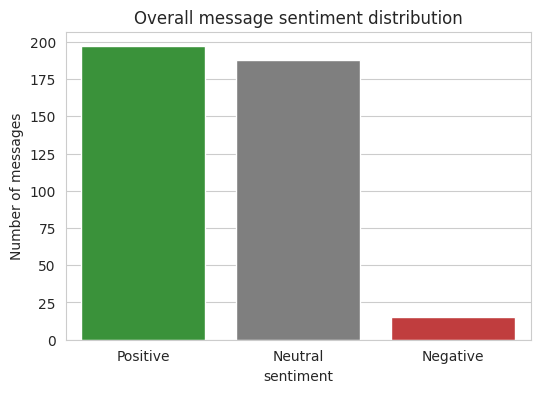

In [30]:
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(
    x=sentiment_counts.index.astype(str),
    y=sentiment_counts.values,
    palette={"Negative": "#d62728", "Neutral": "#7f7f7f", "Positive": "#2ca02c"},
)
plt.title("Overall message sentiment distribution")
plt.ylabel("Number of messages")
plt.show()


/tmp/ipykernel_5446/564998721.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["user", "sentiment"])


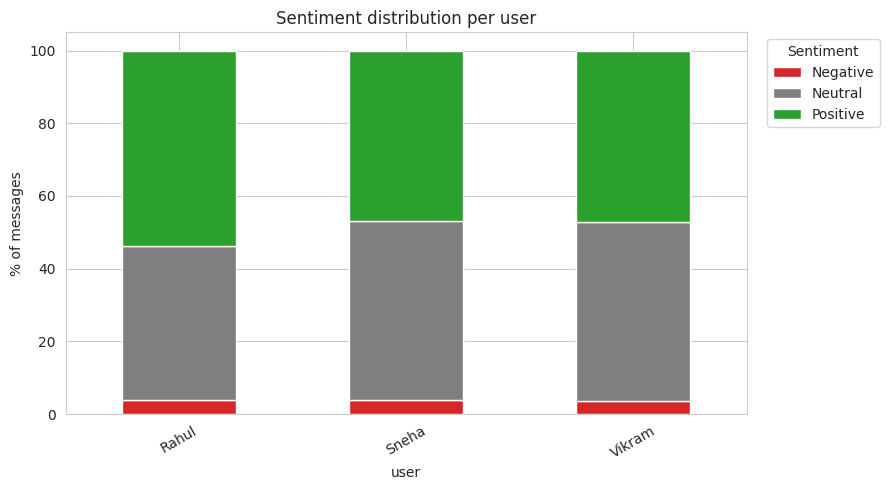

In [31]:
sentiment_by_user = (
    df[df["user"] != "group_notification"]
    .groupby(["user", "sentiment"])
    .size()
    .unstack(fill_value=0)
)
sentiment_by_user_pct = sentiment_by_user.div(sentiment_by_user.sum(axis=1), axis=0) * 100

sentiment_by_user_pct.plot(
    kind="bar", stacked=True, figsize=(9, 5),
    color=["#d62728", "#7f7f7f", "#2ca02c"]
)
plt.title("Sentiment distribution per user")
plt.ylabel("% of messages")
plt.xticks(rotation=30)
plt.legend(title="Sentiment", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()
